In [1]:
# import warnings
# warnings.filterwarnings("ignore")

In [2]:
import re
import string
import joblib
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA

from wordcloud import WordCloud

import nltk
from nltk.probability import FreqDist

import gensim
from gensim import corpora
from gensim.models import Phrases
from gensim.models.phrases import Phraser

In [3]:
import spacy
nlp = spacy.load("uk_core_news_sm")
import uk_core_news_sm
nlp = uk_core_news_sm.load()

### Preprocessing data (adding columns `clean_text` and `label`)

In [4]:
# conn = sqlite3.connect('./data/news.db')
# query = "SELECT * FROM articles"
# df = pd.read_sql_query(query, conn)
# conn.close()

In [5]:
# df = df[(df['date'] >= '2024-04-01 00:00:00') & (df['date'] < '2024-05-01 00:00:00')]

In [6]:
# def preprocess(text):
#     text = text.lower()
#     text = re.sub('\[.*?\]', '', text)
#     text = re.sub("\\W"," ",text) 
#     text = re.sub('https?://\S+|www\.\S+', '', text)
#     text = re.sub('<.*?>+', '', text)
#     text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
#     text = re.sub('\n', '', text)
#     text = re.sub('\w*\d\w*', '', text)
    
#     doc = nlp(text)
#     lemmatized_tokens = [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]
    
#     return ' '.join(lemmatized_tokens)

In [7]:
# seqs_to_del = [
#     'підписуйтесь канал telegram viber',
#     'термінові важливий',
#     'терміновий важливий',
#     'повідомлення війна росія україна читати канал рбк україна telegram',
#     'повідомляти рбк україна ',
#     'рбк україна ',
#     'читати',
    
# #     'україна', 
# #     'український',
# #     'росія',
# #     'російський',
# ]

# def preprocess2(text):
#     for seq in seqs_to_del:
#         text = text.replace(seq, '')
#     text = re.sub(r'\s+', ' ', text)
#     text = text.strip()
#     return text

In [8]:
# df['clean_text'] = df['text'].apply(preprocess)
# df['clean_text'] = df['clean_text'].apply(preprocess2)

In [9]:
# class TextPreprocessor(BaseEstimator, TransformerMixin):
#     def __init__(self):
#         pass
    
#     def fit(self, X, y=None):
#         return self
    
#     def transform(self, X):
#         preprocessed_texts = []
#         for text in X:
#             preprocessed_text = self.preprocess_text(text)
#             preprocessed_texts.append(preprocessed_text)
#         return preprocessed_texts
    
#     def preprocess_text(self, text):
#         text = text.lower()
#         text = re.sub('\[.*?\]', '', text)
#         text = re.sub("\\W"," ",text) 
#         text = re.sub('https?://\S+|www\.\S+', '', text)
#         text = re.sub('<.*?>+', '', text)
#         text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
#         text = re.sub('\n', '', text)
#         text = re.sub('\w*\d\w*', '', text)
#         return text

In [10]:
# model = joblib.load('./models/model_pipeline_1714870823.pkl')

In [11]:
# preds = model.predict_proba(df['title'])

In [12]:
# df['label'] = preds[:,1:]

In [13]:
# df.to_csv('data2024april.csv', index=False)
df = pd.read_csv('data2024april.csv')

In [14]:
df.head()

,id,link,title,text,date,source_id,clean_text,label
0,35122,https://www.pravda.com.ua/news/2024/04/1/7449205/,"В України є дрони, які здатні пролетіти понад ...",Міністр цифрової трансформації Михайло Федоров...,2024-04-01 00:00:00,1,міністр цифровий трансформація михайло федоров...,0.866870
1,35125,https://www.pravda.com.ua/news/2024/04/1/7449196/,Росіяни завдали ракетного удару по Кривому Рог...,Російські війська о 20:35 1 квітня завдали рак...,2024-04-01 00:00:00,1,російський військо квітень завдати ракетний уд...,0.943367
2,35127,https://www.pravda.com.ua/news/2024/04/1/7449191/,ЗМІ: Ізраїль розбомбив консульство Ірану в Сир...,"Сирійські та іранські медіа повідомляють, що і...",2024-04-01 00:00:00,1,сирійський іранський медіа повідомляти ізраїль...,0.615559
3,35130,https://www.pravda.com.ua/news/2024/04/1/7449187/,"ЗСУ знищили над Чорним морем російський дрон ""...",Українські зенітники знищили в акваторії Чорно...,2024-04-01 00:00:00,1,український зенітник знищити акваторія чорний ...,0.668122
4,35132,https://www.pravda.com.ua/news/2024/04/1/7449174/,У російському Бєлгороді повідомили про обстріл...,Місцева влада російського Бєлгорода увечері 1 ...,2024-04-01 00:00:00,1,місцевий влада російський бєлгород увечері кві...,0.984799


### Update the database with data for columns `clean_text` and `label`

In [15]:
# conn = sqlite3.connect('./data/news.db')
# cursor = conn.cursor()

# update_query_1 = """
#     UPDATE articles
#     SET clean_text = ?
#     WHERE title = ?
# """
# update_query_2 = """
#     UPDATE articles
#     SET label = ?
#     WHERE title = ?
# """

# for index, row in df.iterrows():
#     cursor.execute(update_query_1, (row['clean_text'], row['title']))
#     cursor.execute(update_query_2, (row['label'], row['title']))

# conn.commit()
# conn.close()

### Inspecting words in dataset

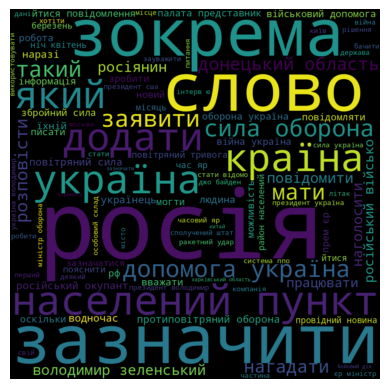

In [16]:
wc = WordCloud(background_color="black", 
               max_words=100,
               max_font_size=256,
               random_state=0, 
               width=1000, 
               height=1000)
wc.generate(' '.join(df['clean_text']))

plt.imshow(wc, interpolation="bilinear")
plt.axis('off')
plt.show()

In [17]:
text_tokens = [txt.split() for txt in df['clean_text']]
texts = ' '.join(df['clean_text'])
texts = texts.split()

In [18]:
freq_dist = FreqDist(texts)
keywords = [word for word, _ in freq_dist.most_common(10)]

print("Частотные ключевые слова:", keywords)

Частотные ключевые слова: ['україна', 'російський', 'військовий', 'росія', 'область', 'квітень', 'український', 'сила', 'оборона', 'країна']


In [19]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['clean_text'])
    
feature_names = vectorizer.get_feature_names_out()
tfidf_scores = X.toarray()[0]
keyword_indices = tfidf_scores.argsort()[-10:][::-1]
keywords_tfidf = [feature_names[i] for i in keyword_indices]
    
print("Ключевые слова по TF-IDF:", keywords_tfidf)

Ключевые слова по TF-IDF: ['перемагати', 'технологічний', 'федоров', 'weltпряма', 'зʼявитися', 'кілометр', 'мова', 'одних', 'вдесятеро', 'вигравати']


In [20]:
all_words = []
for text in df['clean_text']:
    words = text.split()
    all_words.extend(words)

word_counts = Counter(all_words)

length = len(df) * 0.7
common_words = [word for word, count in word_counts.items() if count >= length]

print("Общие слова, которые встречаются в каждом тексте:")
print(common_words)

Общие слова, которые встречаются в каждом тексте:
['україна', 'російський', 'квітень', 'військовий', 'український', 'область', 'росія']


### Topic modeling

In [21]:
text_tokens = [txt.split() for txt in df['clean_text']]

In [22]:
bigram = Phrases(text_tokens, min_count=5, threshold=10)
bigram_phraser = Phraser(bigram)

bigram_text = [bigram_phraser[txt] for txt in text_tokens]

In [23]:
dictionary = corpora.Dictionary(bigram_text)
corpus = [dictionary.doc2bow(txt) for txt in bigram_text]

In [24]:
num_topics = 5
lda_model = gensim.models.LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics)

In [25]:
lda_model.print_topics()
# lda_model.show_topics(formatted=False)

[(0,
  '0.012*"україна" + 0.011*"російський" + 0.009*"ракета" + 0.008*"український" + 0.007*"удар" + 0.007*"дрон" + 0.006*"атака" + 0.006*"росія" + 0.006*"безпілотник" + 0.006*"рф"'),
 (1,
  '0.021*"україна" + 0.008*"ізраїль" + 0.007*"військовий" + 0.006*"український" + 0.006*"допомога" + 0.005*"сша" + 0.005*"ворог" + 0.005*"росіянин" + 0.005*"іран" + 0.004*"російський"'),
 (2,
  '0.032*"україна" + 0.011*"росія" + 0.008*"країна" + 0.007*"сша" + 0.007*"війна" + 0.006*"заявити" + 0.005*"допомога" + 0.005*"російський" + 0.005*"український" + 0.004*"слово"'),
 (3,
  '0.010*"україна" + 0.007*"область" + 0.007*"квітень" + 0.007*"ворог" + 0.005*"сила_оборона" + 0.005*"повідомити" + 0.005*"окупант" + 0.005*"місто" + 0.005*"удар" + 0.005*"населений_пункт"'),
 (4,
  '0.011*"україна" + 0.007*"чоловік" + 0.005*"людина" + 0.005*"мобілізація" + 0.004*"військовий" + 0.004*"громадянин" + 0.004*"документ" + 0.004*"нагадати" + 0.004*"мати" + 0.003*"квітень"')]

In [26]:
# remove = ['україна', 'український', 'росія', 'російський']

for idx, topic in lda_model.print_topics(num_words=5):
    print('Topic: {}'.format(idx))
    words = topic.split('"')[1::2]
#     words = [w for w in words if w not in remove]
    print('Words:', words)

Topic: 0
Words: ['україна', 'російський', 'ракета', 'український', 'удар']
Topic: 1
Words: ['україна', 'ізраїль', 'військовий', 'український', 'допомога']
Topic: 2
Words: ['україна', 'росія', 'країна', 'сша', 'війна']
Topic: 3
Words: ['україна', 'область', 'квітень', 'ворог', 'сила_оборона']
Topic: 4
Words: ['україна', 'чоловік', 'людина', 'мобілізація', 'військовий']


In [27]:
# # Generate word clouds for each topic
# for idx, topic in lda_model.show_topics(formatted=False):
#     word_freq = {word: freq for word, freq in topic}
#     wordcloud = WordCloud(background_color='white').generate_from_frequencies(word_freq)
    
#     # Plot word cloud
#     plt.figure(figsize=(8, 6))
#     plt.imshow(wordcloud, interpolation='bilinear')
#     plt.title('Topic {}'.format(idx))
#     plt.axis('off')
#     plt.show()

In [28]:
# # Plot word frequencies for each topic
# for idx, topic in lda_model.show_topics(formatted=False):
#     word_freq = {word: freq for word, freq in topic}
#     sorted_word_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
#     top_words = sorted_word_freq[:10]  # Select top 10 words
#     words, freqs = zip(*top_words)
    
#     # Plot bar plot
#     plt.figure(figsize=(8, 6))
#     plt.barh(words, freqs, color='skyblue')
#     plt.gca().invert_yaxis()
#     plt.xlabel('Word Frequency')
#     plt.title('Topic {}'.format(idx))
#     plt.show()

In [29]:
# # Подсчет количества статей для каждой темы
# topic_counts = [0] * num_topics  # Создаем список нулей для каждой темы
# for doc_topics in lda_model.get_document_topics(corpus):
#     for topic, _ in doc_topics:
#         topic_counts[topic] += 1

# # Визуализация количества статей для каждой темы
# plt.figure(figsize=(10, 6))
# plt.bar(range(num_topics), topic_counts, color='skyblue')
# plt.xlabel('Topic')
# plt.ylabel('Number of Articles')
# plt.title('Number of Articles per Topic')
# plt.xticks(range(num_topics))
# plt.show()

### Cluster analysis

In [30]:
vectorizer = TfidfVectorizer(max_features=1000)
matrix = vectorizer.fit_transform(df['clean_text'])

In [31]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(matrix)

/home/yaroslav_els/.local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


KMeans(n_clusters=5)

In [32]:
_, topic_counts = np.unique(kmeans.labels_, return_counts=True)

In [33]:
feature_names = vectorizer.get_feature_names_out()
top_keywords = []

for cluster_center in kmeans.cluster_centers_:
    top_keyword_idxs = cluster_center.argsort()[-5:][::-1]
    top_keywords.append([feature_names[idx] for idx in top_keyword_idxs])

In [34]:
top_keywords

[['україна', 'чоловік', 'український', 'мобілізація', 'російський'],
 ['напрямок', 'ворог', 'яр', 'військо', 'російський'],
 ['україна', 'сша', 'допомога', 'президент', 'нато'],
 ['ізраїль', 'іран', 'іранський', 'атака', 'ізраїльський'],
 ['область', 'повітряний', 'удар', 'ракета', 'російський']]

In [35]:
print("Наиболее обсуждаемые темы и их ключевые слова:")
for i, count in enumerate(topic_counts):
    print(f"Тема {i}: {count} статей")
    print("Ключевые слова:", ', '.join(top_keywords[i]))
    print()

Наиболее обсуждаемые темы и их ключевые слова:
Тема 0: 4628 статей
Ключевые слова: україна, чоловік, український, мобілізація, російський

Тема 1: 1153 статей
Ключевые слова: напрямок, ворог, яр, військо, російський

Тема 2: 2640 статей
Ключевые слова: україна, сша, допомога, президент, нато

Тема 3: 400 статей
Ключевые слова: ізраїль, іран, іранський, атака, ізраїльський

Тема 4: 2538 статей
Ключевые слова: область, повітряний, удар, ракета, російський



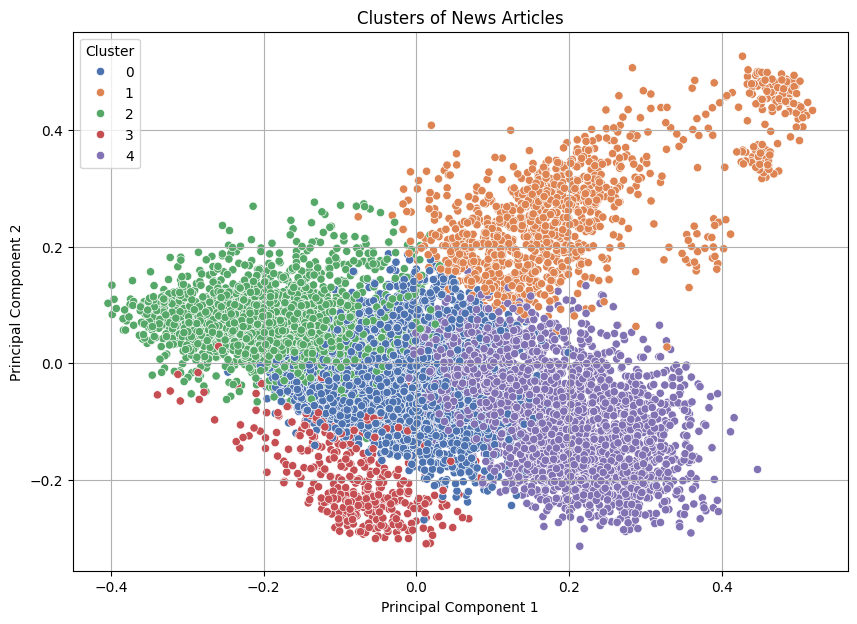

In [36]:
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(matrix.toarray())

plt.figure(figsize=(10, 7))
sns.scatterplot(x=reduced_features[:, 0], 
                y=reduced_features[:, 1], 
                hue=kmeans.labels_, 
                palette='deep', 
                legend='full')
plt.title('Clusters of News Articles')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [41]:
df['kmean_label'] = kmeans.labels_

In [38]:
# topics = list(df['kmean_label'].value_counts().index)
# counts = list(df['kmean_label'].value_counts())
# fake_counts_values = [len(df[(df['kmean_label'] == topic) & (df['label'] < 0.5)]) for topic in topics]

# plt.figure(figsize=(6, 4))
# plt.bar(topics, counts, color='#87cefa', label='Всего статей')
# plt.bar(topics, fake_counts_values, color='#ffc87c', label='Фейковые статьи')

# plt.title('Результаты кластерного анализа')
# plt.xlabel('Темы')
# plt.ylabel('Количество статей')
# plt.legend()
# plt.show()

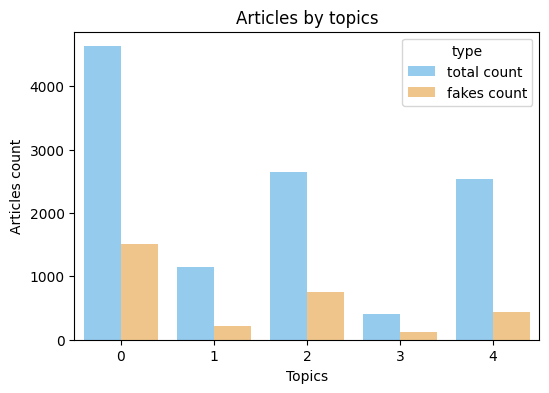

In [42]:
topics = list(df['kmean_label'].value_counts().index)
counts = list(df['kmean_label'].value_counts())
fake_counts_values = [len(df[(df['kmean_label'] == topic) & (df['label'] < 0.5)]) for topic in topics]

df_sns = pd.DataFrame({
    'topic': topics,
    'total count': counts,
    'fakes count': fake_counts_values
})
df_long = df_sns.melt(id_vars='topic', var_name='type', value_name='count')

plt.figure(figsize=(6, 4))
sns.barplot(x='topic', y='count', hue='type', data=df_long, palette=['#87cefa', '#ffc87c'])

plt.title('Articles by topics')
plt.xlabel('Topics')
plt.ylabel('Articles count')
# plt.savefig('my_plot.png')
plt.show()

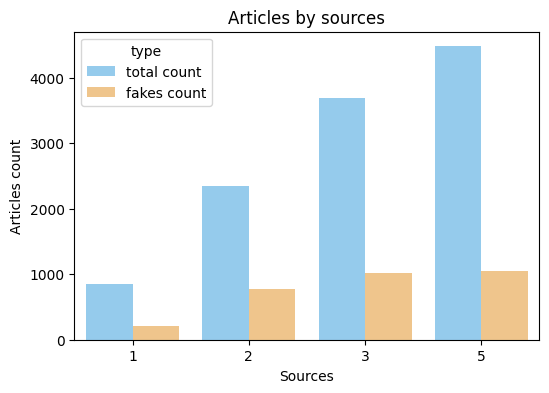

In [43]:
sources = list(df['source_id'].value_counts().index)
counts = list(df['source_id'].value_counts())
fake_counts_values = [len(df[(df['source_id'] == source) & (df['label'] < 0.5)]) for source in sources]

df_sns = pd.DataFrame({
    'source': sources,
    'total count': counts,
    'fakes count': fake_counts_values
})
df_long = df_sns.melt(id_vars='source', var_name='type', value_name='count')

plt.figure(figsize=(6, 4))
sns.barplot(x='source', y='count', hue='type', data=df_long, palette=['#87cefa', '#ffc87c'])

plt.title('Articles by sources')
plt.xlabel('Sources')
plt.ylabel('Articles count')
# plt.savefig('my_plot_2.png')
plt.show()

### Sentiment analysis

In [40]:
from textblob import TextBlob

# Пример текста для анализа
text = "thw movie was terribly good"

# Создание объекта TextBlob
blob = TextBlob(text)

# Анализ тональности текста
sentiment_score = blob.sentiment.polarity

# Определение эмоциональной окраски
if sentiment_score > 0:
    print("Текст положительный.")
elif sentiment_score < 0:
    print("Текст отрицательный.")
else:
    print("Текст нейтральный.")

Текст положительный.
